In [133]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [134]:
class Normalizer:
    def __init__(self):
        self.mean = 0
        self.std = 0


    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)


    def transform(self, X):
        return (X - self.mean) / self.std

# Classification

In [135]:
class GMMClassifier:
    def __init__(self):
        self.X = np.array([])
        self.n = 0
        self.m = 0
        self.z = np.array([])
        self.p = np.array([])
        self.K = 0
        self.cov = np.array([])
        self.mean = np.array([])


    def fit(self, X, z):
        self.X = np.asarray(X)
        self.n = self.X.shape[0]
        self.m = self.X.shape[1] if self.X.ndim > 1 else 1
        self.z = np.asarray(z)

        self.K = len(np.unique(self.z))
        self.p = np.array([np.mean(self.z == k) for k in range(self.K)])
        self.cov = np.array([np.cov(self.X[self.z == k], rowvar=False) for k in range(self.K)])
        self.mean = np.array([np.mean(self.X[self.z == k], axis=0) for k in range(self.K)])


    def gaussian(self, k, x):
        return 1 / ((2 * np.pi) ** (self.m/2) * np.linalg.det(self.cov[k]) ** (1/2)) * np.exp(-1/2 * (x - self.mean[k]).T @ np.linalg.inv(self.cov[k]) @ (x - self.mean[k]))


    def predict(self, X):
        predictions = []

        for x in X:
            t = [self.p[l] * self.gaussian(l, x) for l in range(self.K)]
            sum_t = np.sum(t)
            predictions.append(np.argmax(t /sum_t))

        return np.array(predictions)

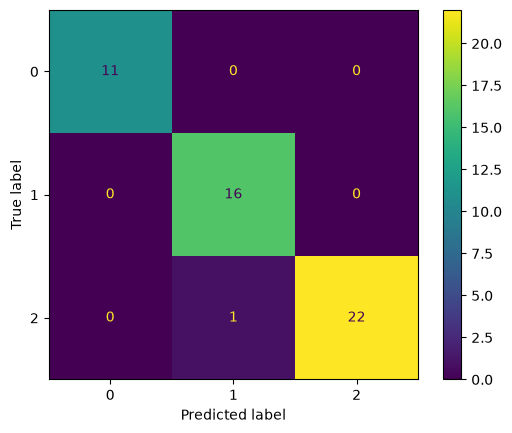

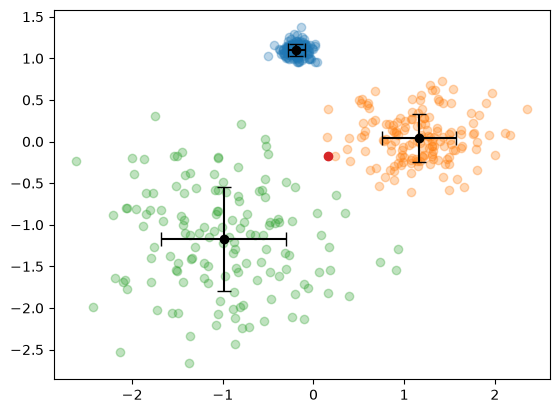

In [136]:
X, z = make_blobs(
    n_samples=500,
    centers=3,
    n_features=2,
    cluster_std=[0.5, 2.0, 4.0],
    random_state=42
)

X_train, X_test, z_train, z_test = train_test_split(X, z, test_size=0.1, random_state=42)

s = Normalizer()
s.fit(X)
X_train = s.transform(X_train)
X_test = s.transform(X_test)

gmm = GMMClassifier()
gmm.fit(X_train, z_train)

z_pred = gmm.predict(X_test)

cm = confusion_matrix(z_test, z_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

X_wrong = X_test[z_pred != z_test]
z_wrong = z_test[z_pred != z_test]

for k in range(gmm.K):
    Xk = X_train[z_train == k]
    plt.scatter(Xk[:, 0], Xk[:, 1], alpha=0.3)
    plt.errorbar(
        gmm.mean[k, 0],
        gmm.mean[k, 1],
        xerr=np.sqrt(gmm.cov[k, 0, 0]),
        yerr=np.sqrt(gmm.cov[k, 1, 1]),
        fmt='o',
        color='black',
        capsize=5
    )

Xk = X_wrong
plt.scatter(Xk[:, 0], Xk[:, 1])

plt.show()


# Clustering

In [137]:
class GMMClusterer:
    def __init__(self):
        self.eps = 1e-3
        self.X = np.array([])
        self.N = 0
        self.m = 0
        self.p = np.array([])
        self.n = np.array([])
        self.z = np.array([])
        self.K = 0
        self.cov = np.array([])
        self.mean = np.array([])


    def f(self, k, x):
        return 1 / ((2 * np.pi) ** (self.m/2) * np.linalg.det(self.cov[k]) ** (1/2)) * np.exp(-1/2 * (x - self.mean[k]).T @ np.linalg.inv(self.cov[k]) @ (x - self.mean[k]))


    def log_f(self, k, x):
        return (
            np.log(self.p[k]) - self.m / 2 * np.log(2 * np.pi) - 1 / 2 * np.log(np.linalg.det(self.cov[k]))
            - 1 / 2 * (x - self.mean[k]).T @ np.linalg.inv(self.cov[k]) @ (x - self.mean[k])
        )


    def fit(self, X, K, eps=1e-3, visualizes=False):
        self.X = np.asarray(X)
        self.N = self.X.shape[0]
        self.m = self.X.shape[1] if self.X.ndim > 1 else 1
        self.K = K
        self.eps = eps

        prev_q = -np.inf
        self.z = np.random.randint(0, self.K, size=self.N)
        self.p = np.array([np.mean(self.z == k) for k in range(self.K)])
        self.cov = np.array([np.cov(self.X[self.z == k], rowvar=False) for k in range(self.K)])
        self.mean = np.array([np.mean(self.X[self.z == k], axis=0) for k in range(self.K)])

        while True:
            ez = np.array([[self.p[k] * self.f(k, x) for k in range(self.K)] for x in self.X])
            ez = np.array([e / np.sum(e) for e in ez])

            self.n = np.array([np.sum(ez[:, k]) for k in range(self.K)])
            self.p = self.n / self.N
            self.mean = np.array([np.sum(ez[:, k, None] * self.X, axis=0) / self.n[k] for k in range(self.K)])
            self.cov = np.array([
                (ez[:, k, None] * (self.X - self.mean[k])).T @ (self.X - self.mean[k]) / self.n[k] for k in range(self.K)
            ])

            q = np.sum([np.sum([ez[i, k] * self.log_f(k, self.X[i]) for i in range(self.N)]) for k in range(self.K)])

            if visualizes:
                self.z = np.argmax(ez, axis=1).T
                for k in range(self.K):
                    Xk = self.X[self.z == k]
                    plt.scatter(Xk[:, 0], Xk[:, 1], alpha=0.3)
                    plt.errorbar(
                        self.mean[k, 0],
                        self.mean[k, 1],
                        xerr=np.sqrt(self.cov[k, 0, 0]),
                        yerr=np.sqrt(self.cov[k, 1, 1]),
                        fmt='o',
                        color='black',
                        capsize=5
                    )

                plt.show()

            if abs(q - prev_q) < self.eps: break
            prev_q = q

        return self.z

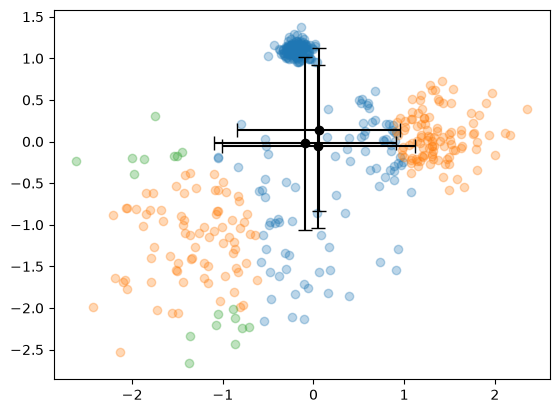

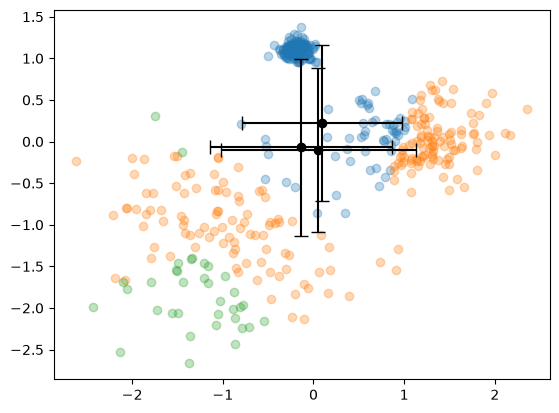

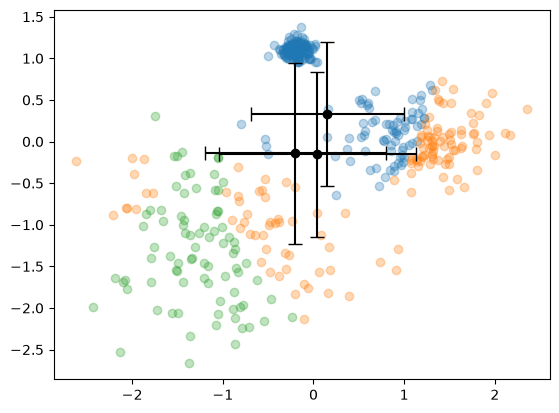

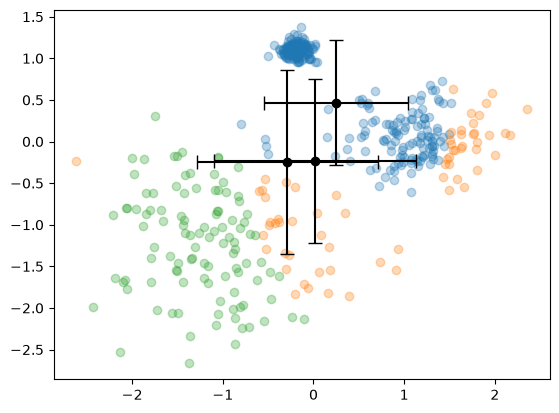

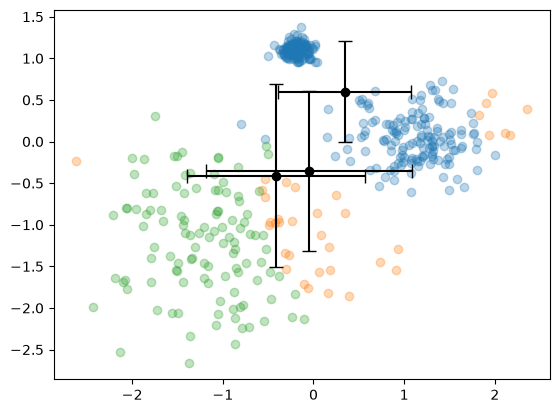

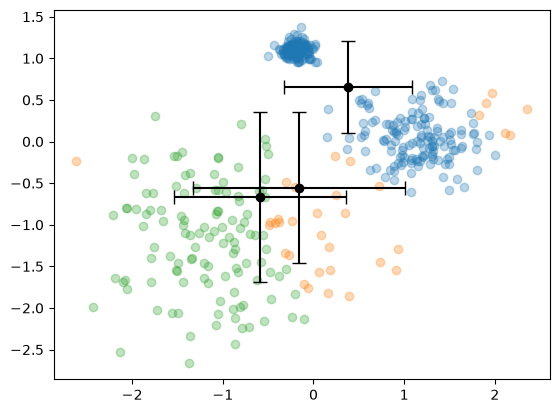

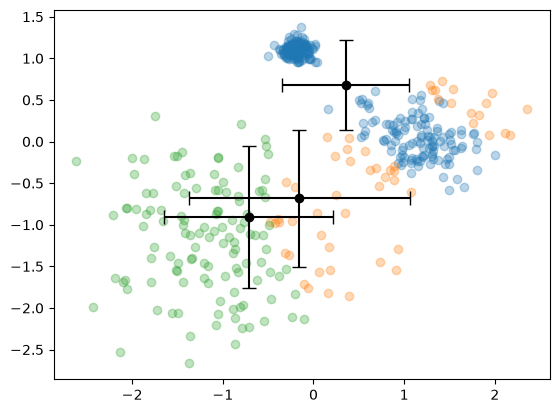

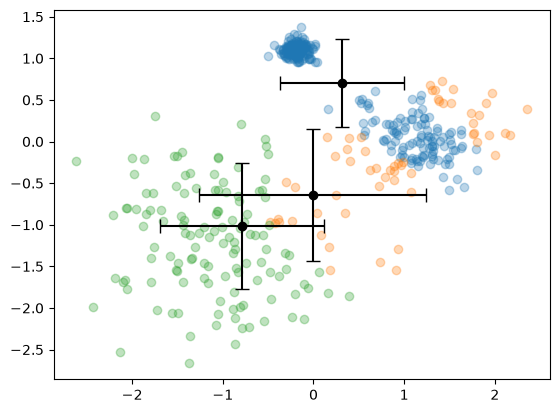

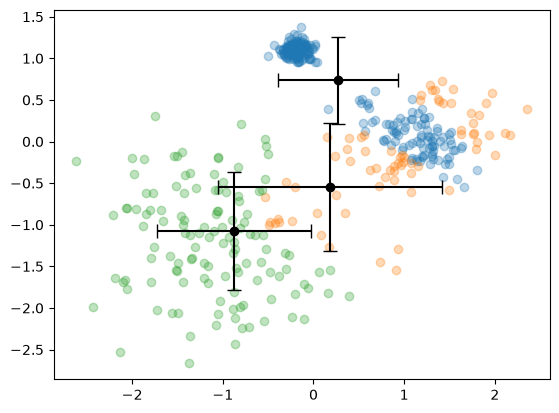

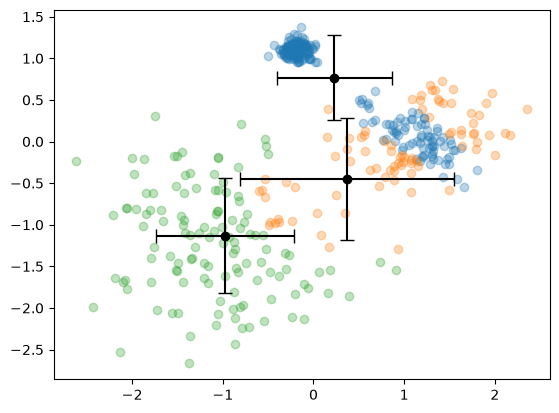

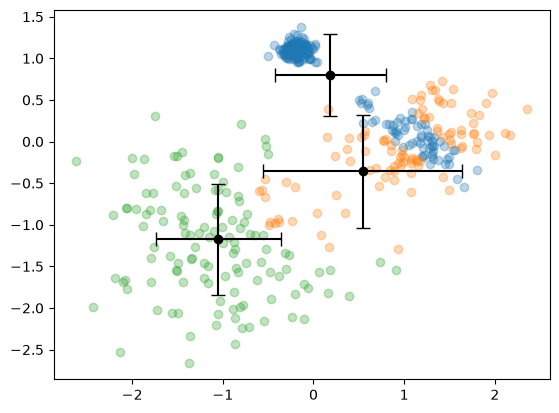

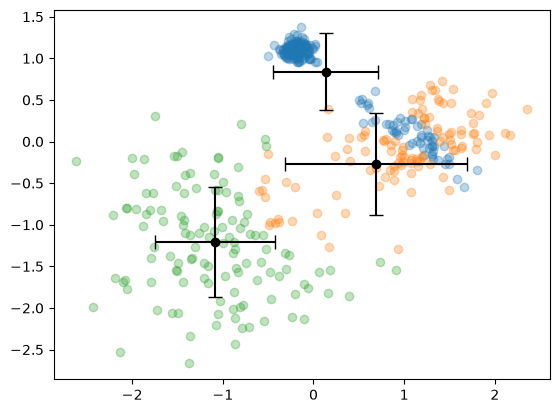

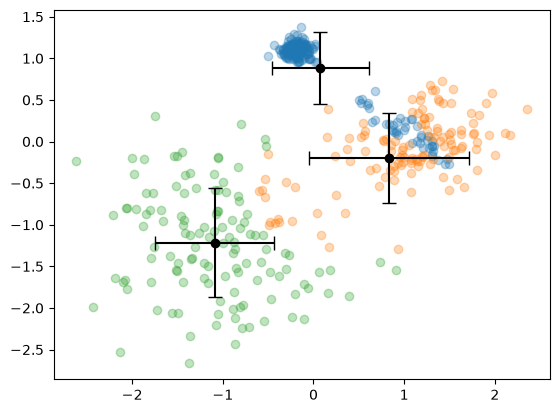

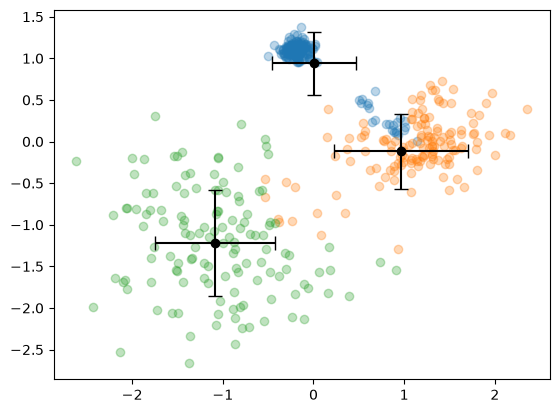

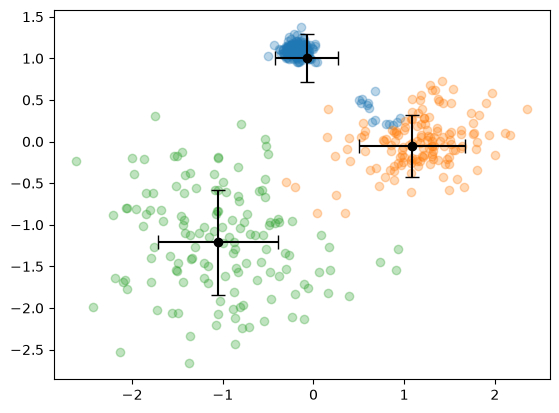

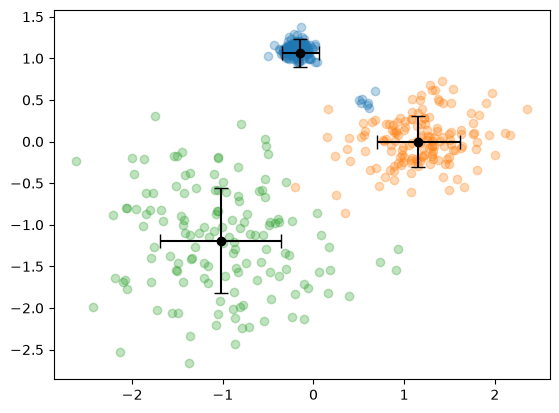

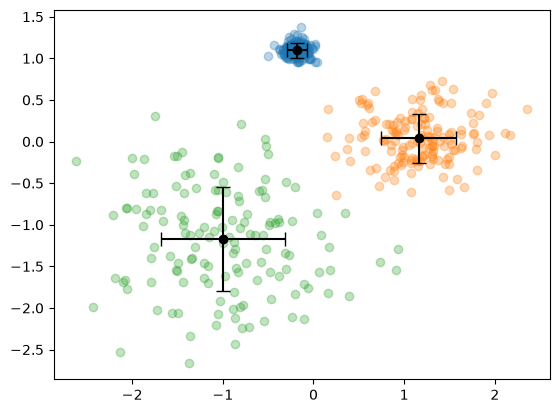

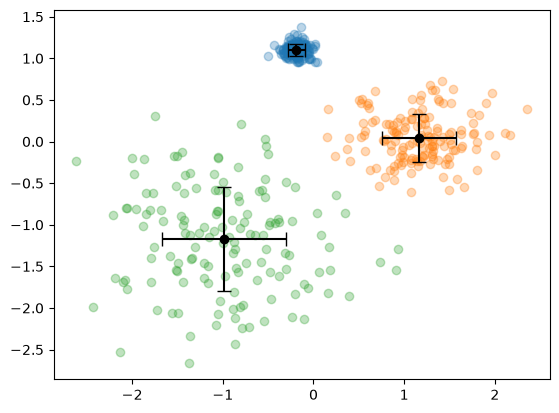

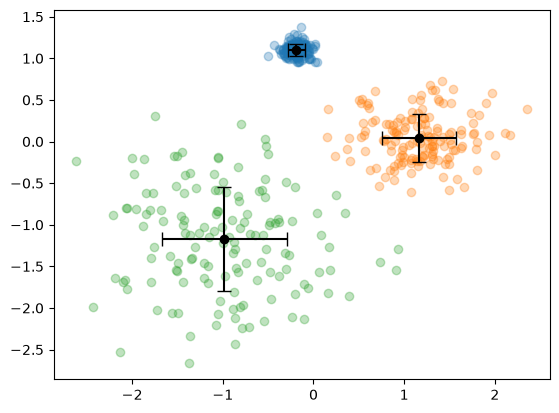

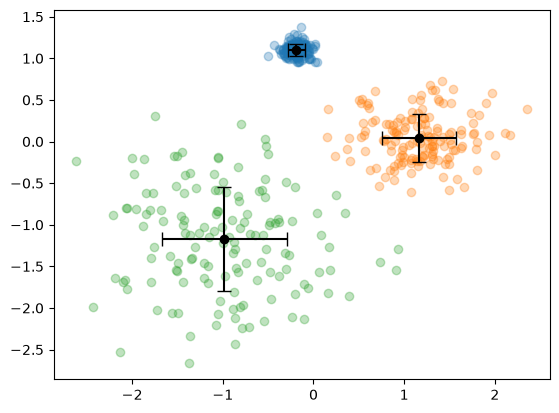

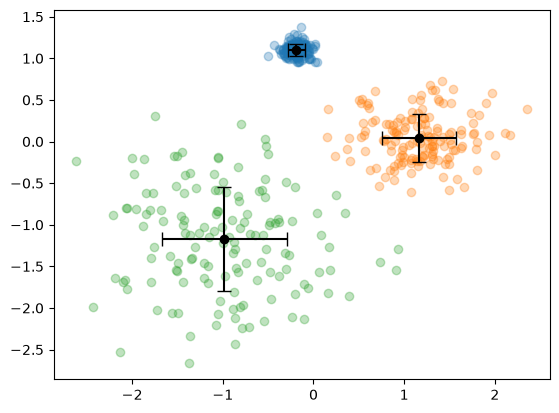

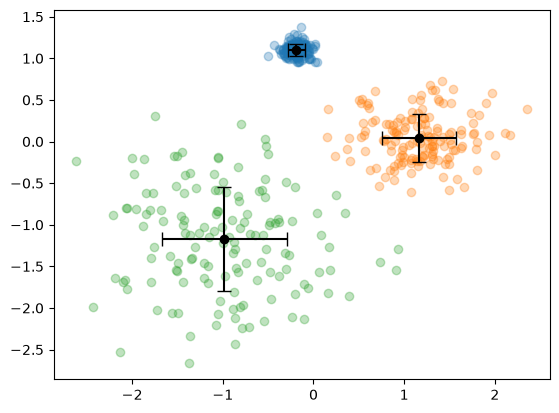

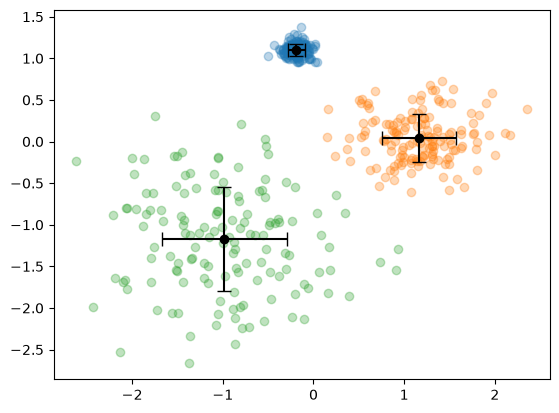

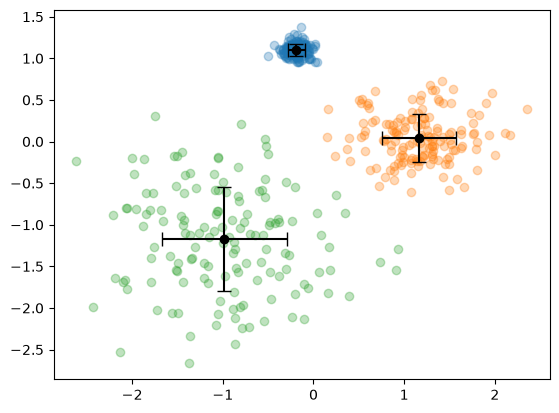

In [139]:
X, _ = make_blobs(
    n_samples=500,
    centers=3,
    n_features=2,
    cluster_std=[0.5, 2.0, 4.0],
    random_state=42
)

X_train, X_test = train_test_split(X, test_size=0.1, random_state=42)

s = Normalizer()
s.fit(X)
X_train = s.transform(X_train)
X_test = s.transform(X_test)

gmm = GMMClusterer()
z_pred = gmm.fit(X_train, K=3, visualizes=True)

# Evaluation

# KMeans